In [107]:
import numpy as np
import matplotlib.pyplot as plt
from src.modulation import gmsk_mod, gaussianLPF
from src.channel import awgn
from src.demodulation import gmsk_demod
from src.spectra import plotWelchPSD, gmsk_psd


# Global Parameters
BT = 0.3
Tb = 10
L = 16
k = 4

fc = 146e6

In [111]:
BT = 0.3
Tb = 10
L = 16
k = 4

fc = 146e6

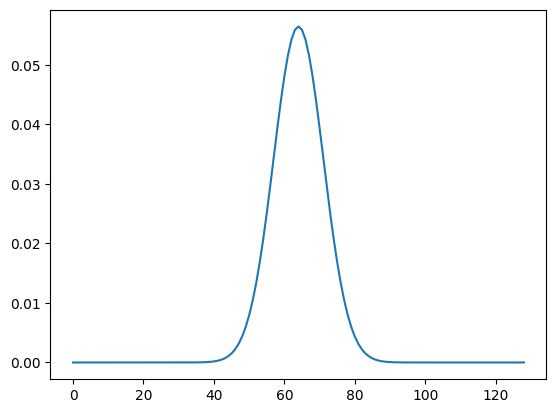

In [112]:
gauss_pulse = gaussianLPF(BT, Tb, L, k)
plt.plot(gauss_pulse)
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


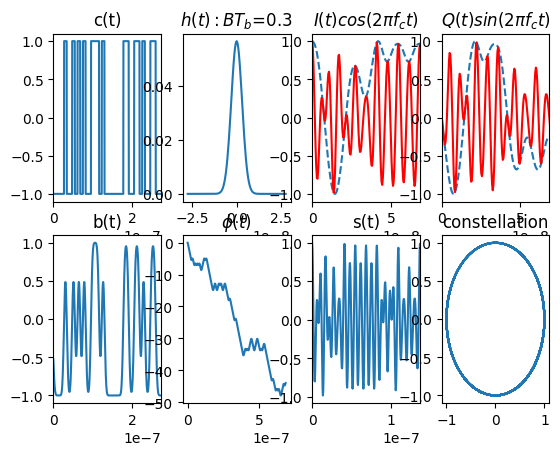

In [113]:
bits = np.random.randint(0, 2, 100)
(s_t, s_complex) = gmsk_mod(bits, fc, L, BT, enable_plot=True)

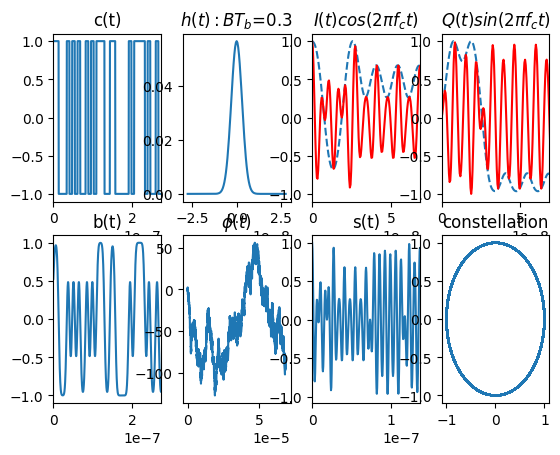

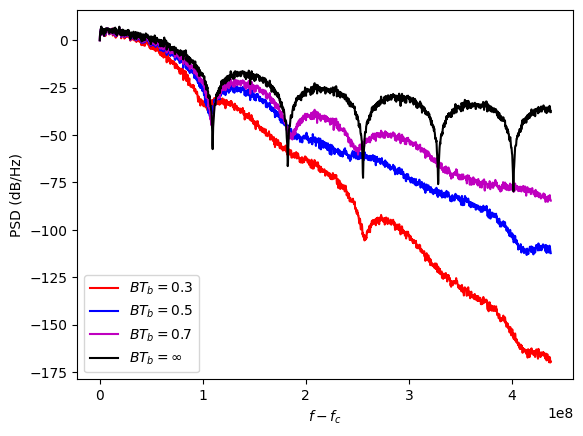

In [115]:
gmsk_psd()

In [117]:
_, s_complex = gmsk_mod(np.random.randint(2, size=10000), fc, L, BT)
a_hat = gmsk_demod(s_complex, L)
len(a_hat)

10000

## Performance simulation of baseband GMSK

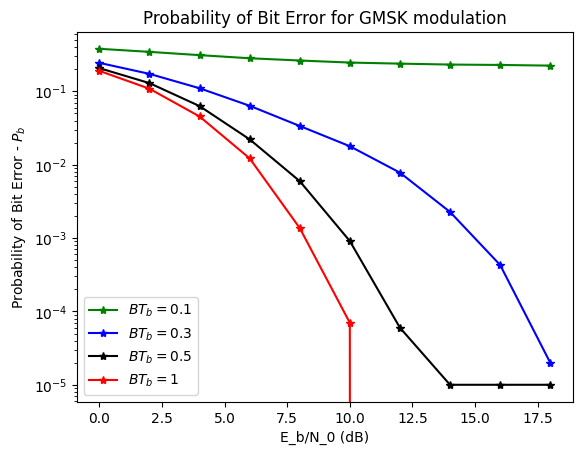

In [119]:
N = 100000
EbN0dB = np.arange(start = 0, stop = 19, step = 2) # Eb/N0 range in dB for simulation
BTs = [0.1, 0.3, 0.5, 1]
fc = 146e6
L = 16

fig, axs = plt.subplots(nrows = 1, ncols = 1)
lineColors = ['g', 'b', 'k', 'r']

for i, BT in enumerate(BTs):
  a = np.random.randint(2, size = N)
  (s_t, s_complex) = gmsk_mod(a, fc, L, BT)
  BER = np.zeros(len(EbN0dB))

  for j, EbN0 in enumerate(EbN0dB):
    r_complex = awgn(s_complex, EbN0)
    a_hat = gmsk_demod(r_complex, L)
    BER[j] = np.sum(a_hat != a)/N

  axs.semilogy(EbN0dB, BER, lineColors[i] + '*-', label = '$BT_b=$'+str(BT))

axs.set_title('Probability of Bit Error for GMSK modulation')
axs.set_xlabel('E_b/N_0 (dB)');axs.set_ylabel('Probability of Bit Error - $P_b$')
axs.legend();fig.show()